In [26]:
import scanpy as sc
import pandas as pd
import hotspot
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import leaves_list
import plotly.express as px
import scvelo as scv

In [12]:
hs = joblib.load(
    "/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/hotspot/epi_hs.create_modules_velocity_pseudotime.pkl"
)
adata_result = sc.read(
    "/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/hotspot/epi_hs.adata_velocity_pseudotime.h5ad"
)

In [14]:
adata = sc.read("/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/epithelial_velo.h5ad")
adata 

AnnData object with n_obs × n_vars = 171184 × 36601
    obs: 'Unnamed: 0', 'barcode', 'leiden_0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pANN', 'DF.classifications', 'tissue', 'donor', 'age', 'gender', 'race', 'study', 'sampleid', 'published_annotation', 'majorclass', 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time'
    obsm: 'X_scVI', 'X_umap'

In [15]:
sc.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)

In [13]:
output_path = "/dfs3b/ruic20_lab/tingty7/projects/ocular_surface/scRNA_wo_fetal/RNA_velocity/hotspot/"

In [16]:
modules = hs.create_modules(min_gene_threshold=160, core_only=True, fdr_threshold=0.01)

In [19]:
ii = leaves_list(hs.linkage)

mod_reordered = hs.modules.iloc[ii]

In [20]:
module_scores = hs.calculate_module_scores()
adata_result.obs["Module1"] = module_scores.loc[adata_result.obs.index, 1].values
adata_result.obs["Module2"] = module_scores.loc[adata_result.obs.index, 2].values
adata_result.obs["Module3"] = module_scores.loc[adata_result.obs.index, 3].values
adata_result.obs["Module4"] = module_scores.loc[adata_result.obs.index, 4].values
adata_result.obs["Module5"] = module_scores.loc[adata_result.obs.index, 5].values
adata_result.obs["Module6"] = module_scores.loc[adata_result.obs.index, 6].values
adata_result.obs["Module7"] = module_scores.loc[adata_result.obs.index, 7].values

Computing scores for 7 modules...


100%|██████████| 7/7 [00:08<00:00,  1.29s/it]


In [21]:
adata_result.obs["Module"] = adata_result.obs[
    [
        "Module1",
        "Module2",
        "Module3",
        "Module4",
        "Module5",
        "Module6",
        "Module7",
    ]
].idxmax(axis=1)

module_list = [
        "Module1",
        "Module2",
        "Module3",
        "Module4",
        "Module5",
        "Module6",
        "Module7",
]
cols = px.colors.qualitative.D3

adata = adata[adata_result.obs.index,]
n = 20
adata_result.obs["velocity_pseudotime_cut"] = pd.cut(
    adata_result.obs.velocity_pseudotime, n
)

In [ ]:
for module in [0, 1, 2, 3, 4, 5, 6]:
    plt.clf()
    z_score_global = [0] * n
    ax = plt.axes([0, 0, 1, 1], frameon=False)
    # Then we disable our xaxis and yaxis completely. If we just say plt.axis('off'),
    # they are still used in the computation of the image padding.
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Even though our axes (plot region) are set to cover the whole image with [0,0,1,1],
    # by default they leave padding between the plotted data and the frame. We use tigher=True
    # to make sure the data gets scaled to the full extents of the axes.
    plt.autoscale(tight=True)

    for gene in mod_reordered[mod_reordered == module + 1].index[:20]:
        print(module)
        print(gene)
        y = adata[:, gene].X.toarray()
        y = [x[0] for x in y]
        n_convolve = 100
        weights = np.ones(n_convolve) / n_convolve
        y_hat = np.convolve(y, weights, mode="same")
        adata_result.obs["y_hat"] = y_hat
        df = (
            adata_result.obs.loc[
                :, ["velocity_pseudotime", "y_hat", "velocity_pseudotime_cut"]
            ]
            .groupby("velocity_pseudotime_cut")
            .mean()
        )
        y_pred = df.y_hat
        x = df.velocity_pseudotime
        z_scores = (y_pred - y_pred.mean()) / (y_pred.std())
        z_score_global = z_score_global + z_scores
        plt.plot(x, z_scores, color=cols[module], linewidth=0.8)
    z_score_global = z_score_global / len(
        mod_reordered[mod_reordered == module + 1].index[:20]
    )
    plt.plot(x, z_score_global, color="black", linewidth=2)
    plt.xticks([])
    plt.yticks([])
    fig = plt.gcf()
    fig.set_size_inches(5, 5)
    plt.yticks(rotation=0)
    plt.savefig(
        output_path + "epi_gene_module_" + str(module + 1) + "_gene_trend.pdf",
        bbox_inches="tight",
        transparent=True,
        dpi=600,
    )
    plt.clf()



In [ ]:
for module in range(7):
    plt.clf()
    fig, ax = plt.subplots(figsize=(5, 5))  # Use standard subplot for visible axes
    z_score_global = 0  # scalar to accumulate

    for gene in mod_reordered[mod_reordered == module + 1].index[:20]:
        print(module, gene)
        y = adata[:, gene].X.toarray().flatten()
        y_hat = np.convolve(y, np.ones(100) / 100, mode="same")
        adata_result.obs["y_hat"] = y_hat

        df = (
            adata_result.obs.loc[:, ["velocity_pseudotime", "y_hat", "velocity_pseudotime_cut"]]
            .groupby("velocity_pseudotime_cut")
            .mean()
        )

        x = df.velocity_pseudotime
        z_scores = (df.y_hat - df.y_hat.mean()) / df.y_hat.std()
        z_score_global += z_scores

        ax.plot(x, z_scores, color=cols[module], linewidth=0.8)

    z_score_global /= 20
    ax.plot(x, z_score_global, color="black", linewidth=2)

    ax.set_xlabel("Pseudotime", fontsize=12)
    ax.set_ylabel("Z-score", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_title(f"Module {module+1}", fontsize=14)

    plt.savefig(
        output_path + f"epi_gene_module_{module + 1}_gene_trend.pdf",
        bbox_inches="tight",
        transparent=True,
        dpi=600,
    )
    plt.close(fig)


In [24]:
sc.pp.normalize_total(adata_result)
sc.pp.scale(adata_result)


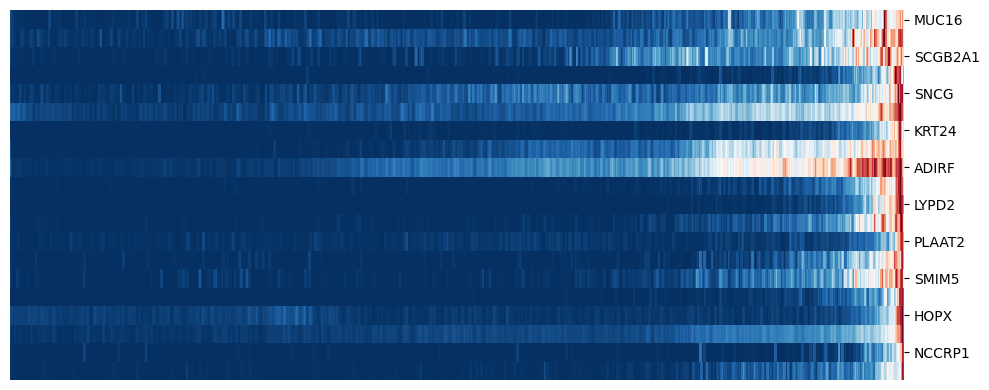

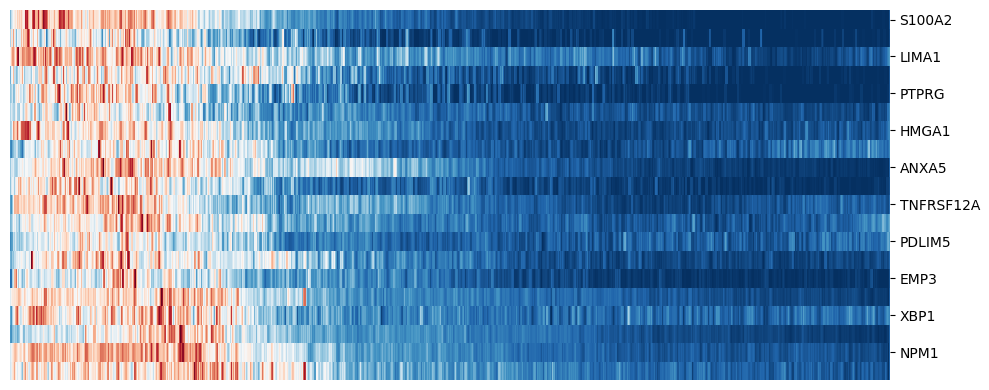

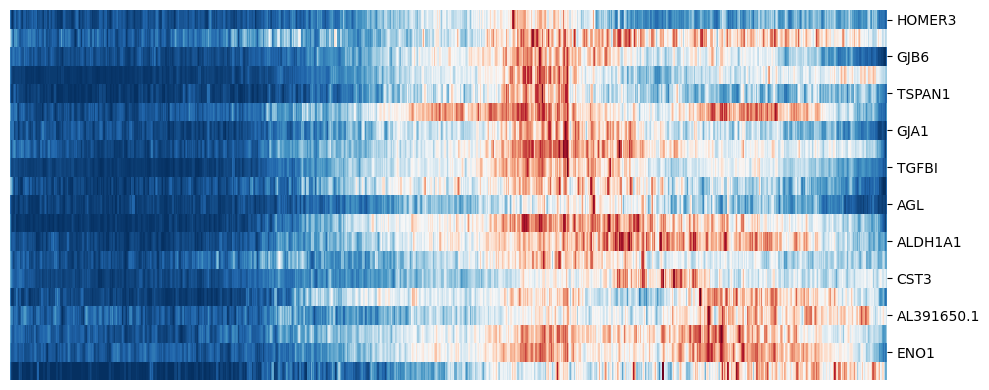

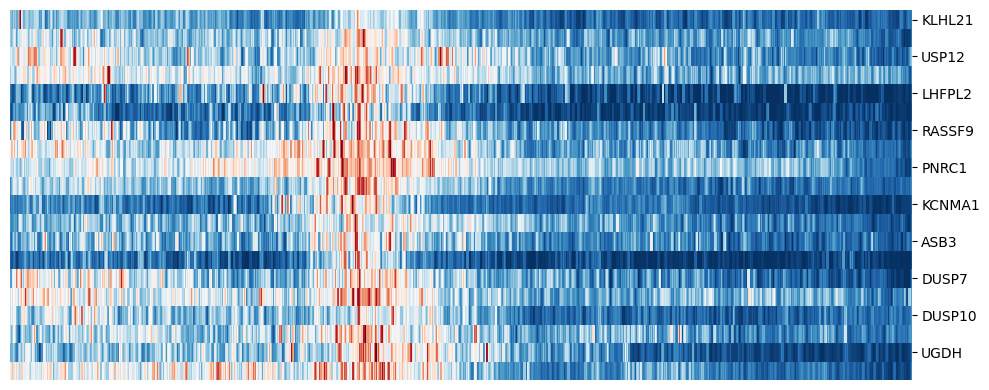

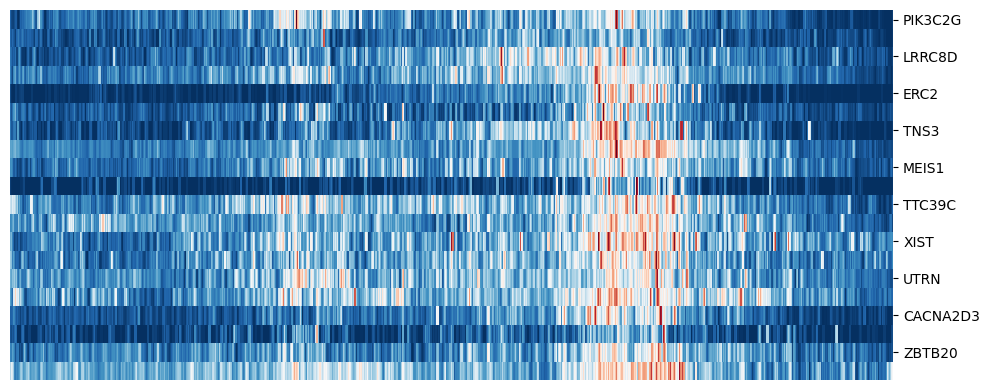

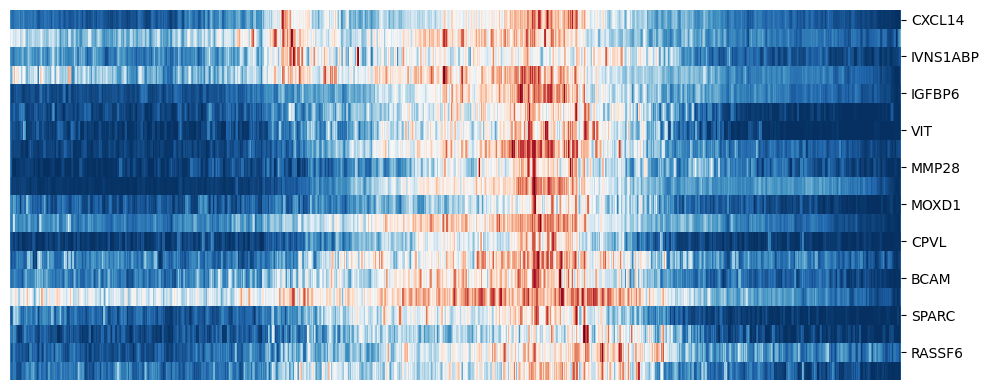

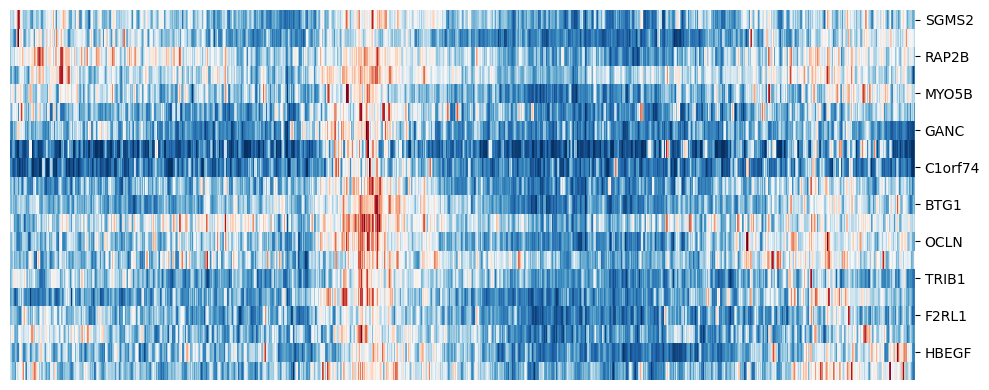

In [36]:
for i in range(1, 8):
    top_genes = mod_reordered[mod_reordered == i][:20].index.tolist()

    scv.pl.heatmap(
        adata_result,
        var_names=top_genes,
        sortby='velocity_pseudotime',
        color_map='RdBu_r',
        #cbar_pos='best',
        colorbar=True,
        figsize=(10, 4),
        show=True  # display the plot
    )

In [37]:
for module in range(1, 8):
    top_genes = mod_reordered[mod_reordered == module][:20].index.tolist()

    scv.pl.heatmap(
        adata_result,
        var_names=top_genes,
        sortby='velocity_pseudotime',
        color_map='RdBu_r',
        #cbar_pos='best',
        colorbar=True,
        show=False
    )

    fig = plt.gcf()
    fig.set_size_inches(10, 4)
    plt.savefig(
        output_path + f"epi_gene_module_{module}_heatmap.pdf",
        bbox_inches="tight",
        transparent=True,
        dpi=300
    )
    plt.close(fig)
